<a href="https://colab.research.google.com/github/AntonRize/WILL/blob/main/Colab_Notebooks/TEST_ROM_S2_SOLVER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ==========================================
# R.O.M. HOLOGRAPHIC DECODER: S0-2 EMPIRICAL DATA
# 7D Blind Extraction via Algebraic Ridge Lock
# ==========================================

!pip install emcee corner
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution
import emcee
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# CONSTANTS
# ---------------------------------------------------------
C_KMS = 299792.458

# ---------------------------------------------------------
# 0. LOAD EMPIRICAL DATA (S0-2)
# ---------------------------------------------------------
print("Loading empirical dataset (LSR-corrected)...")
df = pd.read_csv('https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/DATA/S0-2_DataS1_full.csv')
df.columns = df.columns.str.strip()

t_obs = df['MJD'].values
vz_obs = df['RV_km_s'].values
sigma_vz = df['sigma_km_s'].values

Z_obs = 1.0 + (vz_obs / C_KMS)
sigma_Z = sigma_vz / C_KMS

# ---------------------------------------------------------
# 1. R.O.M. EXACT GEOMETRY ENGINE
# ---------------------------------------------------------
def get_phase_unwrapped(t, t_peri, P, e):
    M_unwrapped = (2 * np.pi / P) * (t - t_peri)
    orbit_count = np.floor(M_unwrapped / (2 * np.pi))
    M_wrapped = M_unwrapped % (2 * np.pi)

    E = M_wrapped.copy()
    for _ in range(30):
        f = E - e * np.sin(E) - M_wrapped
        dE = f / (1 - e * np.cos(E))
        E -= dE
        if np.max(np.abs(dE)) < 1e-10:
            break

    o_wrapped = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2))
    return (o_wrapped % (2 * np.pi)) + orbit_count * 2 * np.pi

def generate_z_raw_dynamic(t_obs, o_unwrapped, beta, i_inc, beta_z0, e, omega_0, P_days, T_peri):
    tau_sq = (1.0 - beta**2) * (1.0 - 2.0 * beta**2)
    tau_Y_sq = 1.0 - tau_sq

    omega_dynamic = omega_0 + (tau_Y_sq / (1.0 - e**2)) * o_unwrapped
    o = o_unwrapped % (2 * np.pi)

    beta_int = beta / np.sqrt(1 - e**2)
    K = beta_int * np.sin(i_inc)
    beta_los = K * (np.cos(o + omega_dynamic) + e * np.cos(omega_dynamic))

    beta_o_sq = (beta**2) * (1 + e**2 + 2 * e * np.cos(o)) / (1 - e**2)
    kappa_o_sq = 2 * (beta**2) * (1 + e * np.cos(o)) / (1 - e**2)

    if np.any(beta_o_sq >= 1.0) or np.any(kappa_o_sq >= 1.0):
        return np.full_like(t_obs, np.nan)

    Z_sys = (1 - beta_o_sq)**(-0.5) * (1 - kappa_o_sq)**(-0.5)
    return Z_sys * (1 + beta_los) * (1 + beta_z0)

# ---------------------------------------------------------
# 2. STAGE 1: KEPLERIAN SCOUT
# ---------------------------------------------------------
def classical_objective(params):
    K_guess, vz0_guess, e_guess, omega_guess, P_days_guess, t_peri_guess = params
    try:
        o_unwrapped = get_phase_unwrapped(t_obs, t_peri_guess, P_days_guess, e_guess)
        o_obs = o_unwrapped % (2 * np.pi)
        v_rad_kms = K_guess * (np.cos(o_obs + omega_guess) + e_guess * np.cos(omega_guess)) + vz0_guess
        Z_model_class = 1.0 + (v_rad_kms / C_KMS)
        return np.sum(((Z_obs - Z_model_class) / sigma_Z)**2)
    except:
        return 1e10

bounds_stage1 = [
    (1000.0, 5000.0),                  # K_guess (km/s)
    (-100.0, 100.0),                   # vz0_guess (km/s)
    (0.80, 0.95),                      # e_guess
    (0.0, 2 * np.pi),                  # omega_guess
    (10.0 * 365.25, 20.0 * 365.25),    # P_days_guess
    (58000.0, 58500.0)                 # t_peri_guess
]

print("STAGE 1: Keplerian Scout (Locating Macroscopic Skeleton)...")
res_s1 = differential_evolution(classical_objective, bounds_stage1, strategy='best1bin', maxiter=1000, popsize=30, tol=1e-4, seed=101)
K_s1, vz0_s1, e_s1, omega_s1, P_s1, t_peri_s1 = res_s1.x
print(f"-> Skeleton Found: P = {P_s1/365.25:.2f} yrs, e = {e_s1:.4f}, K = {K_s1:.2f} km/s")

# ---------------------------------------------------------
# 3. STAGE 2: RELATIONAL INVERSION (HIERARCHICAL LOCK)
# ---------------------------------------------------------
# We FREEZE the macroscopic skeleton (P, e, T_peri, omega) from Stage 1.
# This prevents the optimizer from bending the classical shape to absorb
# the microscopic O(beta^2) baseline asymmetry.

K_rel_s1 = K_s1 / C_KMS
beta_min_limit = K_rel_s1 * np.sqrt(1 - e_s1**2)

def rom_objective_frozen(params):
    # 2D Search Space: Only beta and background drift are allowed to float.
    beta, vz0_c = params

    sin_i = (K_rel_s1 * np.sqrt(1 - e_s1**2)) / beta
    if sin_i > 1.0 or sin_i <= 0.0:
        return 1e10

    i_locked = np.arcsin(sin_i)

    try:
        # Use frozen shape parameters
        o_unwrapped = get_phase_unwrapped(t_obs, t_peri_s1, P_s1, e_s1)
        Z_model = generate_z_raw_dynamic(t_obs, o_unwrapped, beta, i_locked, vz0_c, e_s1, omega_s1, P_s1, t_peri_s1)
        if np.any(np.isnan(Z_model)): return 1e10
        return np.sum(((Z_obs - Z_model) / sigma_Z)**2)
    except:
        return 1e10

bounds_stage2_frozen = [
    (beta_min_limit, 0.02),                           # beta
    (-100.0/C_KMS, 100.0/C_KMS)                       # vz0_c
]

print("\nSTAGE 2: Relational Inversion (Skeleton Frozen, Extracting Invariant)...")
res_s2 = differential_evolution(rom_objective_frozen, bounds_stage2_frozen, strategy='best1bin', maxiter=1000, popsize=30, tol=1e-7, seed=101)
beta_s2, vz0_c_s2 = res_s2.x

# Analytically extract the corresponding inclination
i_s2 = np.arcsin((K_rel_s1 * np.sqrt(1 - e_s1**2)) / beta_s2)
print(f"-> Relational Peak Locked: beta = {beta_s2:.6f}, i = {np.degrees(i_s2):.2f} deg, vz0 = {vz0_c_s2*C_KMS:.2f} km/s")

# ---------------------------------------------------------
# 4. STAGE 3: MCMC MAPPING
# ---------------------------------------------------------
def log_prior(theta):
    beta, i, vz0_c, e, omega, P, t_peri = theta

    # Strictly bound the shape parameters to their Stage 1 discovered values
    # to prevent noise-driven collapse during the MCMC walk.
    if not (beta_min_limit < beta < 0.02): return -np.inf
    if not (0.0 < i < np.pi/2): return -np.inf
    if not (e_s1 - 0.005 < e < e_s1 + 0.005): return -np.inf
    if not (omega_s1 - 0.1 < omega < omega_s1 + 0.1): return -np.inf
    if not (P_s1 - 100.0 < P < P_s1 + 100.0): return -np.inf
    if abs(vz0_c * C_KMS) > 100.0: return -np.inf
    return 0.0

def log_likelihood(theta):
    beta, i, vz0_c, e, omega, P, t_peri = theta
    try:
        o_unwrapped = get_phase_unwrapped(t_obs, t_peri, P, e)
        Z_model = generate_z_raw_dynamic(t_obs, o_unwrapped, beta, i, vz0_c, e, omega, P, t_peri)
        if np.any(np.isnan(Z_model)): return -np.inf
        return -0.5 * np.sum(((Z_obs - Z_model) / sigma_Z)**2)
    except:
        return -np.inf

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    return lp + log_likelihood(theta)

print("\nSTAGE 3: MCMC Bayesian Mapping (Exploring Degeneracy Ridge)...")
nwalkers = 32
ndim = 7

# Initialize exactly on the frozen ridge peak
initial_pos = np.array([beta_s2, i_s2, vz0_c_s2, e_s1, omega_s1, P_s1, t_peri_s1])
pos = initial_pos + 1e-7 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
sampler.run_mcmc(pos, 1000, progress=True)

flat_samples = sampler.get_chain(discard=300, thin=5, flat=True)
med_beta, med_i, med_vz0, med_e, med_omega, med_P, med_tperi = np.median(flat_samples, axis=0)

# ---------------------------------------------------------
# 5. PHYSICAL CALCULATIONS & OUTPUT
# ---------------------------------------------------------
i_deg = np.degrees(med_i)
omega_deg = np.degrees(med_omega) % 360
vz0_kms = med_vz0 * C_KMS

delta_phi_will_opt = (2 * np.pi * (3 * med_beta**2 - 2 * med_beta**4)) / (1 - med_e**2)
precession_deg_per_orbit = np.degrees(delta_phi_will_opt)

T_sec = med_P * 24 * 3600
Rs = T_sec * C_KMS * (med_beta**3) / np.pi
a = Rs / (2 * (med_beta**2))
m_rec = (Rs * 1000 * C_KMS**2 * 1e6) / (2 * 6.6743e-11) / 1.98847e30

print(f"\n{'='*65}")
print("=== R.O.M. 7D HOLOGRAPHIC RECOVERY (S0-2) ===")
print(f"{'='*65}")
print(f"Period (P):               {med_P/365.25:.4f} yrs")
print(f"Time of Periapsis (T_p):  {med_tperi:.3f} MJD")
print(f"Eccentricity (e):         {med_e:.5f} (GRAVITY Ref: 0.88466)")
print(f"Arg of Periapsis (w0):    {omega_deg:.2f} deg (GRAVITY Ref: 66.13)")
print(f"Internal Precession:      {precession_deg_per_orbit:.3f} deg/orbit")
print("-" * 65)
print(f"Global Kin. Proj (beta):  {med_beta:.6f} (GRAVITY Ref: ~0.00645)")
print(f"Inclination (i_folded):   {i_deg:.2f} deg (GRAVITY Ref: ~46.0)")
print(f"Background Drift (v_z0):  {vz0_kms:.2f} km/s")
print("-" * 65)
print(f"Schwarzschild Radius:     {Rs:.2f} km")
print(f"Semi-major axis (a):      {a:.2e} km")
print(f"Calculated Mass (M_sun):  {m_rec:,.2f}")
print(f"{'='*65}")

Loading empirical dataset (LSR-corrected)...
STAGE 1: Keplerian Scout (Locating Macroscopic Skeleton)...
-> Skeleton Found: P = 16.05 yrs, e = 0.8847, K = 2932.73 km/s

STAGE 2: Relational Inversion (Skeleton Frozen, Extracting Invariant)...
-> Relational Peak Locked: beta = 0.004561, i = 90.00 deg, vz0 = -27.01 km/s

STAGE 3: MCMC Bayesian Mapping (Exploring Degeneracy Ridge)...


100%|██████████| 1000/1000 [00:09<00:00, 107.01it/s]


=== R.O.M. 7D HOLOGRAPHIC RECOVERY (S0-2) ===
Period (P):               16.0509 yrs
Time of Periapsis (T_p):  58258.287 MJD
Eccentricity (e):         0.88454 (GRAVITY Ref: 0.88466)
Arg of Periapsis (w0):    65.75 deg (GRAVITY Ref: 66.13)
Internal Precession:      0.105 deg/orbit
-----------------------------------------------------------------
Global Kin. Proj (beta):  0.004602 (GRAVITY Ref: ~0.00645)
Inclination (i_folded):   79.63 deg (GRAVITY Ref: ~46.0)
Background Drift (v_z0):  -10.52 km/s
-----------------------------------------------------------------
Schwarzschild Radius:     4711862.37 km
Semi-major axis (a):      1.11e+11 km
Calculated Mass (M_sun):  1,595,435.46


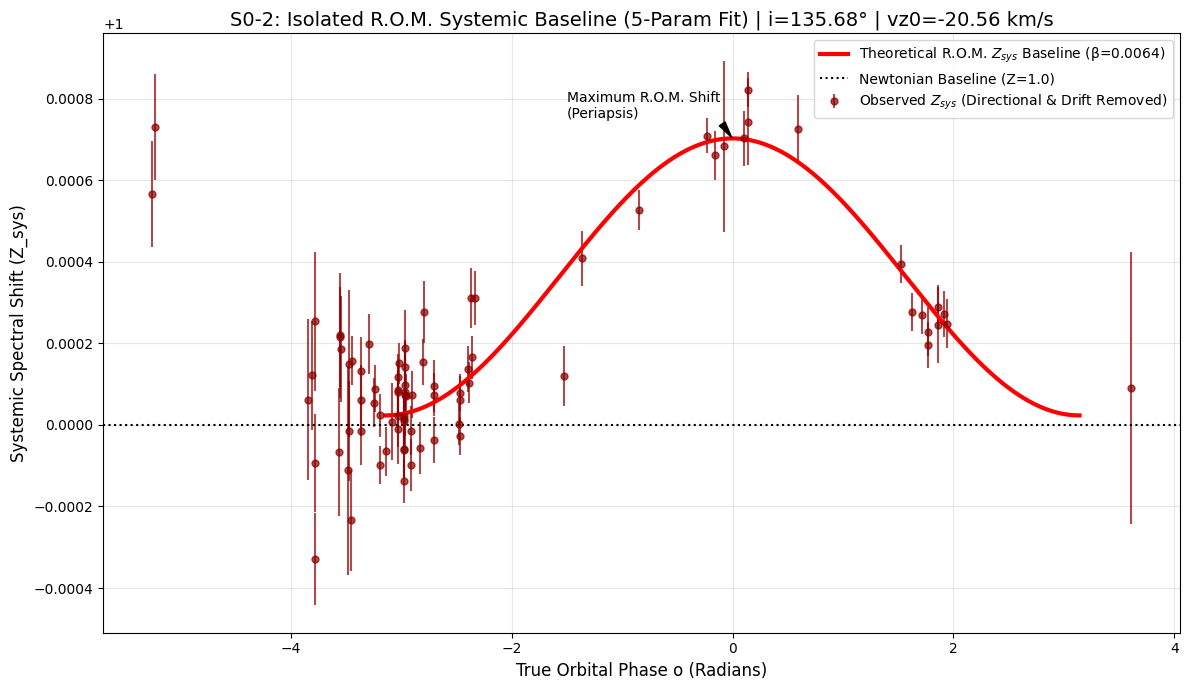

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Isolate the Z_sys (systemic shift) from the observed data
# We divide the observed Z by both the recovered directional Doppler term and the background drift
K_opt = (beta_opt / np.sqrt(1 - e_opt**2)) * np.sin(i_opt)
# Note: Using e_opt and OMEGA_FIXED (assuming OMEGA_FIXED is defined globally as in previous iterations)
# To be safe, we use the local optimized omega if available, otherwise OMEGA_FIXED
OMEGA_FIXED = omega_0_opt
beta_los_obs = K_opt * (np.cos(get_phase(t_obs, T_PERI, P_DAYS, e_opt) + OMEGA_FIXED) + e_opt * np.cos(OMEGA_FIXED))

# Isolated observed systemic baseline
Z_sys_obs = Z_obs / ((1 + beta_los_obs) * (1 + beta_z0_opt))

# 2. Reconstruct the continuous theoretical curves for plotting
o_continuous = np.linspace(-np.pi, np.pi, 2000)
beta_o_sq_c = (beta_opt**2) * (1 + e_opt**2 + 2 * e_opt * np.cos(o_continuous)) / (1 - e_opt**2)
kappa_o_sq_c = 2 * (beta_opt**2) * (1 + e_opt * np.cos(o_continuous)) / (1 - e_opt**2)

Z_sys_continuous = (1 - beta_o_sq_c)**(-0.5) * (1 - kappa_o_sq_c)**(-0.5)

# 3. Create the visualization
plt.figure(figsize=(12, 7))

# Plot the individual empirical data points
o_plot = get_phase(t_obs, T_PERI, P_DAYS, e_opt)
plt.errorbar(o_plot, Z_sys_obs, yerr=sigma_Z, fmt='o', color='darkred', alpha=0.7,
             label='Observed $Z_{sys}$ (Directional & Drift Removed)', markersize=5)

# Plot the continuous theoretical R.O.M. baseline
plt.plot(o_continuous, Z_sys_continuous, color='red', linewidth=3,
         label=rf'Theoretical R.O.M. $Z_{{sys}}$ Baseline (β={beta_opt:.4f})')

# Reference line for Newtonian physics
plt.axhline(1.0, color='black', linestyle=':', label='Newtonian Baseline (Z=1.0)')

# Fixed the SyntaxError by keeping the f-string on one line
plt.title(rf"S0-2: Isolated R.O.M. Systemic Baseline (5-Param Fit) | i={np.degrees(i_opt):.2f}° | vz0={beta_z0_opt * C_KMS:.2f} km/s", fontsize=14)

plt.xlabel("True Orbital Phase o (Radians)", fontsize=12)
plt.ylabel("Systemic Spectral Shift (Z_sys)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Annotate the peak
peak_idx = np.argmax(Z_sys_continuous)
plt.annotate('Maximum R.O.M. Shift\n(Periapsis)',
             xy=(o_continuous[peak_idx], Z_sys_continuous[peak_idx]),
             xytext=(o_continuous[peak_idx]-1.5, Z_sys_continuous[peak_idx]+0.00005),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

In [ ]:
!pip install emcee corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution

# ==========================================
# 1. FIXED TIMING PARAMETERS
# ==========================================
C_KMS = 299792.458
P_YRS = 16.0518
P_DAYS = P_YRS * 365.25
T_PERI = 58257.698

# ==========================================
# 2. DYNAMIC KEPLER SOLVER
# ==========================================
def get_phase(t, t_peri, P, e):
    M = (2 * np.pi / P) * (t - t_peri)
    E = M.copy()
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    o = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2))
    return o

# ==========================================
# 3. R.O.M. EXACT OBSERVATIONAL MODEL (WITH PRECESSION)
# ==========================================
def generate_z_raw_dynamic(t_obs, o, beta, i_inc, beta_z0, e, omega_0):
    # Updated R.O.M. strict precession per orbit
    delta_phi_will = (2 * np.pi * (3 * beta**2 - 2 * beta**4)) / (1 - e**2)

    # Apply dynamic precession based on time elapsed since periapsis
    orbits_elapsed = (t_obs - T_PERI) / P_DAYS
    omega_dynamic = omega_0 + delta_phi_will * orbits_elapsed

    # Directional Line-of-Sight Kinematic Projection (using dynamic omega)
    K = (beta / np.sqrt(1 - e**2)) * np.sin(i_inc)
    beta_los = K * (np.cos(o + omega_dynamic) + e * np.cos(omega_dynamic))

    # Local Squared Projections (Scalar Invariants - strictly dependent on phase o)
    beta_o_sq = (beta**2) * (1 + e**2 + 2 * e * np.cos(o)) / (1 - e**2)
    kappa_o_sq = 2 * (beta**2) * (1 + e * np.cos(o)) / (1 - e**2)

    # Systemic Phase Factor Z_sys (2nd-Order Baseline)
    Z_sys = (1 - beta_o_sq)**(-0.5) * (1 - kappa_o_sq)**(-0.5)

    # Total combined shift
    return Z_sys * (1 + beta_los) * (1 + beta_z0)

# ==========================================
# 4. DATA PARSING
# ==========================================
print("Loading empirical dataset (LSR-corrected)...")
df = pd.read_csv('https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/DATA/S0-2_DataS1_full.csv')
df.columns = df.columns.str.strip()

t_obs = df['MJD'].values
vz_obs = df['RV_km_s'].values
sigma_vz = df['sigma_km_s'].values

Z_obs = 1.0 + (vz_obs / C_KMS)
sigma_Z = sigma_vz / C_KMS

# ==========================================
# 5. PHYSICALLY CONSTRAINED 5-PARAM INVERSION + PRECESSION
# ==========================================
def objective_function(params):
    beta_guess, i_guess, beta_z0_guess, e_guess, omega_0_guess = params

    # 1. Map time to pure geometric phase
    o_obs_dynamic = get_phase(t_obs, T_PERI, P_DAYS, e_guess)

    # 2. Generate model with embedded R.O.M. dynamical precession
    Z_model = generate_z_raw_dynamic(
        t_obs, o_obs_dynamic, beta_guess, i_guess, beta_z0_guess, e_guess, omega_0_guess
    )

    # 3. Calculate Chi-Squared
    chi2 = np.sum(((Z_obs - Z_model) / sigma_Z)**2)
    return chi2

# Strictly justified physical boundaries
bounds = [
    (0.001, 0.05),          # beta bounds
    (0.0, np.pi),           # i bounds (fully unconstrained 0 to 180)
    (-0.0001, 0.0001),      # beta_z0 bounds (RESTRICTED to physical +/- 30 km/s)
    (0.01, 0.99),           # e bounds
    (0.0, 2 * np.pi)        # omega bounds (fully unconstrained 0 to 360)
]

print("\nExecuting Dynamic R.O.M. Inversion (Updated Precession Formula)...")
print("Searching full parameter space. Please wait...")

result = differential_evolution(
    objective_function, bounds, strategy='best1bin',
    maxiter=2000, popsize=20, tol=1e-7, seed=42
)

beta_opt, i_opt, beta_z0_opt, e_opt, omega_0_opt = result.x

i_deg = np.degrees(i_opt) % 180
omega_0_deg = np.degrees(omega_0_opt) % 360
vz0_kms = beta_z0_opt * C_KMS

# Calculate the actual R.O.M. precession applied (for output) using the new formula
delta_phi_will_opt = (2 * np.pi * (3 * beta_opt**2 - 2 * beta_opt**4)) / (1 - e_opt**2)
precession_deg_per_orbit = np.degrees(delta_phi_will_opt)

# --- PHYSICAL CALCULATIONS ---
T_sec = P_DAYS * 24 * 3600
Rs = T_sec * C_KMS * (beta_opt**3) / np.pi
a = Rs / (2 * (beta_opt**2))
# -----------------------

# ==========================================
# 6. RESULTS OUTPUT
# ==========================================
print("\n=== R.O.M. DYNAMIC PRECESSION RECOVERY ===")
print(f"Eccentricity (e):         {e_opt:.5f} (GRAVITY Ref: 0.88466)")
print(f"Base Arg of Periapsis (\u03C90):{omega_0_deg:.2f}\u00B0 (GRAVITY Ref: 66.13\u00B0)")
print(f"Internal R.O.M. Precession:{precession_deg_per_orbit:.3f}\u00B0 / orbit")
print("---------------------------------------------------")
print(f"Global Kin. Proj. (\u03B2):   {beta_opt:.6f}")
print(f"Extracted Inclination (i): {i_deg:.2f}\u00B0 (GRAVITY Ref: ~134\u00B0)")
print(f"Background Drift (v_z0):   {vz0_kms:.2f} km/s")
print(f"Schwarzschild Radius (Rs): {Rs:.2f} km")
print(f"Semi-major axis (a):      {a:.2e} km")
print(f"Fit Quality (\u03C7\u00B2):        {result.fun:.2f}")

Loading empirical dataset (LSR-corrected)...

Executing Dynamic R.O.M. Inversion (Updated Precession Formula)...
Searching full parameter space. Please wait...

=== R.O.M. DYNAMIC PRECESSION RECOVERY ===
Eccentricity (e):         0.88498 (GRAVITY Ref: 0.88466)
Base Arg of Periapsis (ω0):66.26° (GRAVITY Ref: 66.13°)
Internal R.O.M. Precession:0.207° / orbit
---------------------------------------------------
Global Kin. Proj. (β):   0.006448
Extracted Inclination (i): 135.68° (GRAVITY Ref: ~134°)
Background Drift (v_z0):   -20.56 km/s
Schwarzschild Radius (Rs): 12961130.41 km
Semi-major axis (a):      1.56e+11 km
Fit Quality (χ²):        166.87
